In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


DATA CLEANING

In [4]:
df.fillna(0, inplace=True)

DATA ANALYSIS


In [5]:
## Total Sales
total_sales = df['Sales'].sum()
print("total Sales: ",total_sales)

total Sales:  2261536.7827000003


In [6]:
## SALES BY CATEGORY
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


In [7]:
## SALES BY REGION
df.groupby('Region')['Sales'].sum()

,Sales
Region,
Central,492646.9132
East,669518.7260
South,389151.4590
West,710219.6845


In [8]:
## SALES BY SEGMENT
sales_segment = df.groupby('Segment')['Sales'].sum()
print(sales_segment)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


In [9]:
## TOP 10 PRODUCTS
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [10]:
## TOP 10 STATES
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_states)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


In [11]:
## MONTHLY SALES TREND
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()
print(monthly_sales)

Order Date
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


DATA VISUALIZATION

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

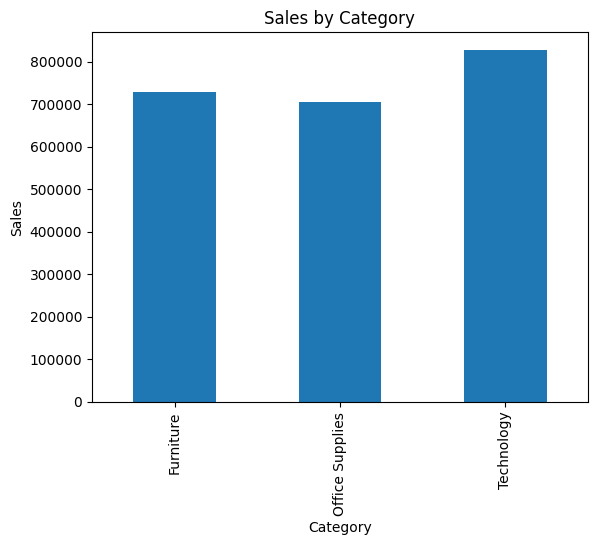

In [13]:
## SALES BY CATEGORY (BAR)
sales_category = df.groupby('Category')['Sales'].sum()
sales_category.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

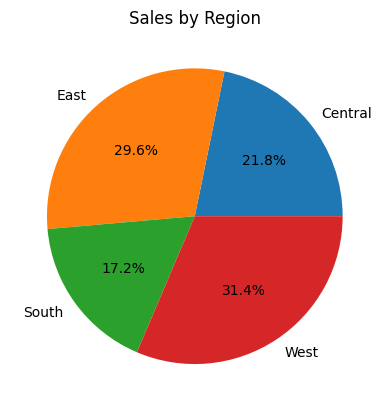

In [14]:
## SALES BY REGION (PIE)
sales_region = df.groupby('Region')['Sales'].sum()
sales_region.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Region")
plt.ylabel("")
plt.show()

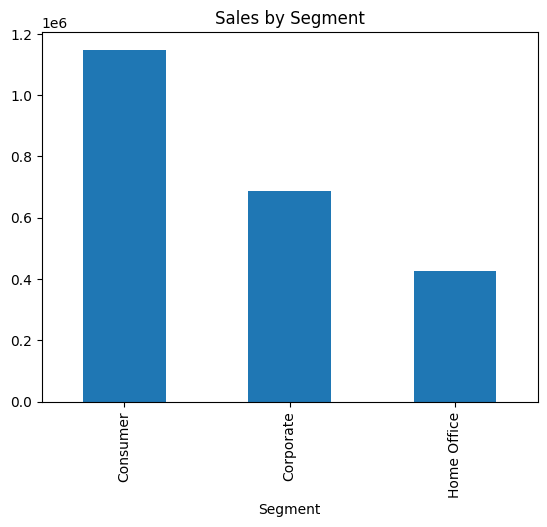

In [15]:
## SALES BY SEGMENT
sales_segment = df.groupby('Segment')['Sales'].sum()
sales_segment.plot(kind='bar')
plt.title("Sales by Segment")
plt.show()

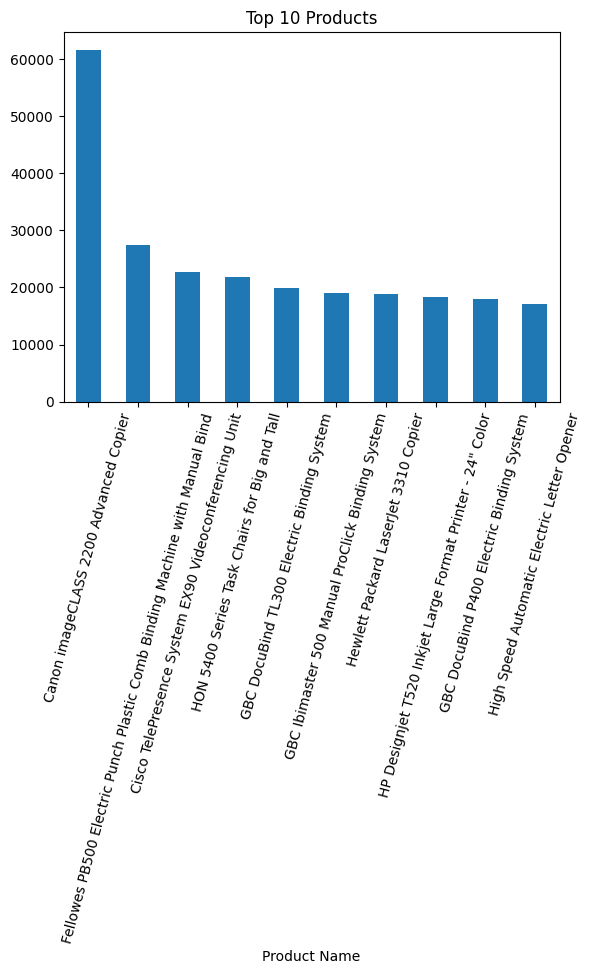

In [16]:
## TOP 10 PRODUCTS
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.xticks(rotation=75)
plt.show()

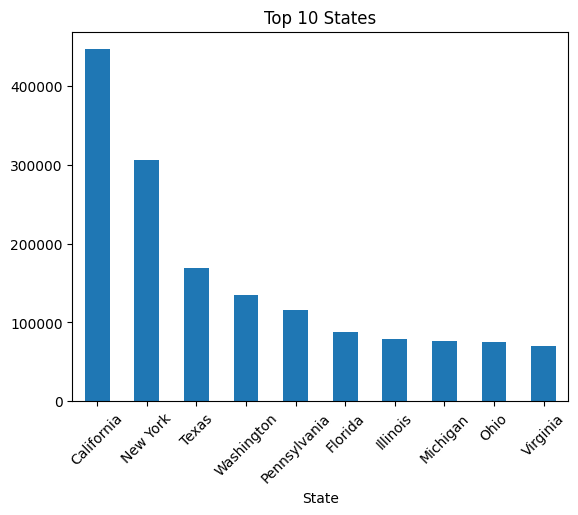

In [17]:
## TOP 10 STATES
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
top_states.plot(kind='bar')
plt.title("Top 10 States")
plt.xticks(rotation=45)
plt.show()

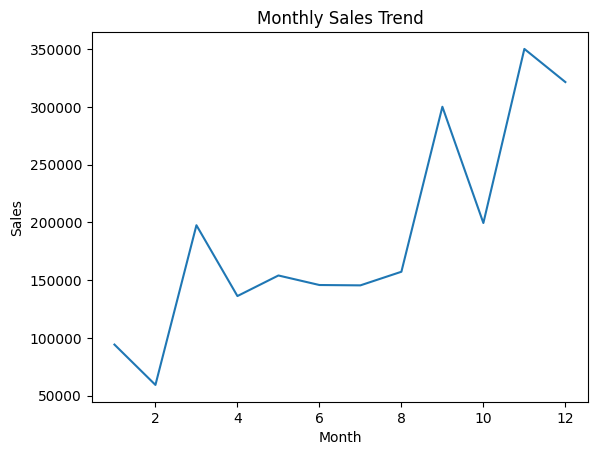

In [18]:

## MONTHLY SALES TREND
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()